# Nettoyage et consolidation des données

Ce notebook assemble les trois sources collectées (LCSQA, Météo-France, IREP),
réalise les jointures spatiales et temporelles, construit les features et 
la variable cible, analyse les valeurs manquantes et sauvegarde le DataFrame
consolidé final sur S3.

## Pipeline

1. Chargement des données brutes depuis S3
2. Jointure spatiale entre LCSQA et  Météo-France (station la plus proche)
3. Jointure spatiale entre LCSQA et IREP (densité d'émissions dans un rayon de 5 km)
4. Construction des features temporelles et des lags PM2.5
5. Construction de la variable cible (dépassement seuil 25 µg/m³ / 24h)
6. Analyse des valeurs manquantes
7. Nettoyage et sélection des colonnes
8. Sauvegarde sur S3

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_loader import load_lcsqa, load_meteo, load_irep, verifier_s3
from src.spatial     import join_meteo_to_lcsqa, compute_irep_density
from src.features    import add_temporal_features, add_lags, add_target

# 1. chargement des données brutes 

In [2]:
df_lcsqa = load_lcsqa()
print(f"LCSQA  : {df_lcsqa.shape[0]:,} lignes | {df_lcsqa['code_station'].nunique()} stations")
print(f"Période: {df_lcsqa['datetime_debut'].min()} → {df_lcsqa['datetime_debut'].max()}")

2026-04-21 10:43:55,765 - INFO - LCSQA : 20 fichiers trouvés
2026-04-21 10:43:55,980 - INFO -   lcsqa_pm25_20210101_20210331.csv : 27252 lignes
2026-04-21 10:43:56,180 - INFO -   lcsqa_pm25_20210401_20210630.csv : 26339 lignes
2026-04-21 10:43:56,373 - INFO -   lcsqa_pm25_20210701_20210930.csv : 28595 lignes
2026-04-21 10:43:56,573 - INFO -   lcsqa_pm25_20211001_20211231.csv : 28643 lignes
2026-04-21 10:43:56,782 - INFO -   lcsqa_pm25_20220101_20220331.csv : 33728 lignes
2026-04-21 10:43:57,028 - INFO -   lcsqa_pm25_20220401_20220630.csv : 34928 lignes
2026-04-21 10:43:57,266 - INFO -   lcsqa_pm25_20220701_20220930.csv : 35312 lignes
2026-04-21 10:43:57,507 - INFO -   lcsqa_pm25_20221001_20221231.csv : 35527 lignes
2026-04-21 10:43:57,767 - INFO -   lcsqa_pm25_20230101_20230331.csv : 38766 lignes
2026-04-21 10:43:58,037 - INFO -   lcsqa_pm25_20230401_20230630.csv : 39294 lignes
2026-04-21 10:43:58,267 - INFO -   lcsqa_pm25_20230701_20230930.csv : 39510 lignes
2026-04-21 10:43:58,506 - 

LCSQA  : 722,740 lignes | 18 stations
Période: 2021-01-01 00:00:00 → 2025-12-31 22:00:00


In [3]:
df_meteo = load_meteo()
print(f"Météo  : {df_meteo.shape[0]:,} lignes | {df_meteo['code_station_meteo'].nunique()} stations")
print(f"Période: {df_meteo['datetime_meteo'].min()} → {df_meteo['datetime_meteo'].max()}")

2026-04-21 10:44:01,615 - INFO - Météo : 16 fichiers trouvés
2026-04-21 10:44:06,382 - INFO -   HOR_departement_75_periode_2020-2024.csv.gz : 261860 lignes
2026-04-21 10:44:07,350 - INFO -   HOR_departement_75_periode_2025-2026.csv.gz : 68171 lignes
2026-04-21 10:44:17,468 - INFO -   HOR_departement_77_periode_2020-2024.csv.gz : 575554 lignes
2026-04-21 10:44:20,485 - INFO -   HOR_departement_77_periode_2025-2026.csv.gz : 170351 lignes
2026-04-21 10:44:28,769 - INFO -   HOR_departement_78_periode_2020-2024.csv.gz : 458907 lignes
2026-04-21 10:44:30,646 - INFO -   HOR_departement_78_periode_2025-2026.csv.gz : 124739 lignes
2026-04-21 10:44:35,658 - INFO -   HOR_departement_91_periode_2020-2024.csv.gz : 273800 lignes
2026-04-21 10:44:37,174 - INFO -   HOR_departement_91_periode_2025-2026.csv.gz : 67937 lignes
2026-04-21 10:44:37,770 - INFO -   HOR_departement_92_periode_2020-2024.csv.gz : 43753 lignes
2026-04-21 10:44:37,995 - INFO -   HOR_departement_92_periode_2025-2026.csv.gz : 11363 

Météo  : 2,512,754 lignes | 58 stations
Période: 2020-01-01 00:00:00 → 2026-04-19 10:00:00


In [6]:
df_irep = load_irep()
print(f"IREP   : {df_irep.shape[0]:,} lignes | {df_irep['identifiant'].nunique()} établissements")
print(f"Années : {sorted(df_irep['annee'].unique())}")

2026-04-21 10:45:16,587 - INFO - IREP : 9796 lignes | 379 établissements


IREP   : 9,796 lignes | 379 établissements
Années : [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


## 2. Jointures spatiales

### 2.1 LCSQA - Météo-France

Pour chaque station LCSQA, on associe la station météo active la plus proche via la distance Haversine. Le merge est ensuite temporel exact sur l'heure.

Les stations météo inactives (moins de 1000 mesures de température) sont exclues du mapping pour éviter des associations avec des stations fermées.

In [7]:
df = join_meteo_to_lcsqa(df_lcsqa, df_meteo)
print(f"\nAprès jointure météo : {df.shape[0]:,} lignes")
print(f"Taux remplissage température : {df['temperature_c'].notna().mean():.1%}")
print(f"\nTaux par station :")
print(df.groupby('code_station')['temperature_c'].apply(
    lambda x: x.notna().mean()
).round(3).to_string())

2026-04-21 10:45:21,990 - INFO - Stations météo complètes (temp + vent + pluie + humidité) : 21 / 58
2026-04-21 10:45:22,273 - INFO - Mapping LCSQA → Météo :
2026-04-21 10:45:22,275 - INFO -   FR04002 → LONGCHAMP (9.5 km)
2026-04-21 10:45:22,276 - INFO -   FR04004 → PARIS-MONTSOURIS (7.8 km)
2026-04-21 10:45:22,276 - INFO -   FR04024 → LE BOURGET (2.9 km)
2026-04-21 10:45:22,277 - INFO -   FR04031 → PARIS-MONTSOURIS (5.6 km)
2026-04-21 10:45:22,278 - INFO -   FR04034 → PARIS-MONTSOURIS (5.8 km)
2026-04-21 10:45:22,279 - INFO -   FR04048 → LE BOURGET (16.0 km)
2026-04-21 10:45:22,280 - INFO -   FR04055 → PARIS-MONTSOURIS (4.5 km)
2026-04-21 10:45:22,280 - INFO -   FR04058 → LE BOURGET (7.0 km)
2026-04-21 10:45:22,281 - INFO -   FR04066 → COURDIMANCHE (12.0 km)
2026-04-21 10:45:22,282 - INFO -   FR04122 → MELUN (9.3 km)
2026-04-21 10:45:22,283 - INFO -   FR04131 → PARIS-MONTSOURIS (5.8 km)
2026-04-21 10:45:22,283 - INFO -   FR04150 → LONGCHAMP (4.1 km)
2026-04-21 10:45:22,284 - INFO -   


Après jointure météo : 722,740 lignes
Taux remplissage température : 99.9%

Taux par station :
code_station
FR04002    0.999
FR04004    1.000
FR04024    1.000
FR04031    1.000
FR04034    1.000
FR04048    1.000
FR04055    1.000
FR04058    1.000
FR04066    1.000
FR04122    0.999
FR04131    1.000
FR04150    1.000
FR04156    1.000
FR04173    1.000
FR04180    1.000
FR04181    0.994
FR04328    0.997
FR04329    1.000


### 2.2 LCSQA - IREP

Pour chaque station LCSQA et chaque année, on calcule la somme des émissions PM des installations industrielles dans un rayon de 5 km.

**Limite :** 
les données IREP 2023-2024 présentent uniquement 
des valeurs `< seuil` non quantifiables. La variable IREP est donc disponible 
uniquement pour 2021-2022 (34.6% des observations). Des NaN pour 2023-2025 
seront donc observés et sont justifiés.

In [8]:
df = compute_irep_density(df, df_irep)
print(f"\nAprès jointure IREP : {df.shape[0]:,} lignes")
print(f"Taux remplissage IREP : {df['densite_emission_pm_kg'].notna().mean():.1%}")

2026-04-21 10:45:42,092 - INFO - IREP PM : 996 lignes | années : [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


2026-04-21 10:45:42,920 - INFO - Après jointure IREP : 722740 lignes
2026-04-21 10:45:42,920 - INFO - Taux de remplissage nb_installations_5km : 78.2%



Après jointure IREP : 722,740 lignes
Taux remplissage IREP : 78.2%


## 3. Construction des features

In [9]:
df = add_temporal_features(df)
df = add_lags(df)
df = add_target(df)

print(f"Shape après features : {df.shape}")
print(f"\nTaux de dépassement : {df['depasse_seuil_24h'].mean():.1%}")
print(f"Distribution cible :")
print(df['depasse_seuil_24h'].value_counts(dropna=False))

2026-04-21 10:45:53,073 - INFO - Features temporelles ajoutées : heure, jour_semaine, mois, annee, is_weekend, saison
2026-04-21 10:45:53,618 - INFO - Lags PM2.5 ajoutés : lag1h, lag6h, lag24h, roll24h, roll72h
2026-04-21 10:45:53,623 - INFO - Taux de remplissage lags : lag1h=97.1% | lag24h=97.1% | roll24h=98.1%
2026-04-21 10:45:53,992 - INFO - Variable cible ajoutée : depasse_seuil_24h (seuil = 25.0 µg/m³)
2026-04-21 10:45:53,993 - INFO - Taux de dépassement global : 18.7%
2026-04-21 10:45:53,998 - INFO - Distribution : 0 (pas de dépassement) = 581800 | 1 (dépassement) = 133550 | NaN = 7390


Shape après features : (722740, 45)

Taux de dépassement : 18.7%
Distribution cible :
depasse_seuil_24h
0       581800
1       133550
<NA>      7390
Name: count, dtype: Int64


## 4. Analyse des valeurs manquantes

Colonnes avec valeurs manquantes :
taux_de_saisie            100.0
couverture_temporelle     100.0
couverture_de_donnees     100.0
nb_installations_5km       21.8
densite_emission_pm_kg     21.8
pm25_lag24h                 2.9
pm25_lag6h                  2.9
pm25_lag1h                  2.9
pm25_brute                  2.9
pm25_valide                 2.9
pm25_roll24h                1.9
pm25_roll72h                1.6
pm25_max_24h                1.0
depasse_seuil_24h           1.0
vent_direction_deg          0.4
pluie_mm                    0.4
vent_vitesse_ms             0.1
humidite_pct                0.1
temperature_c               0.1


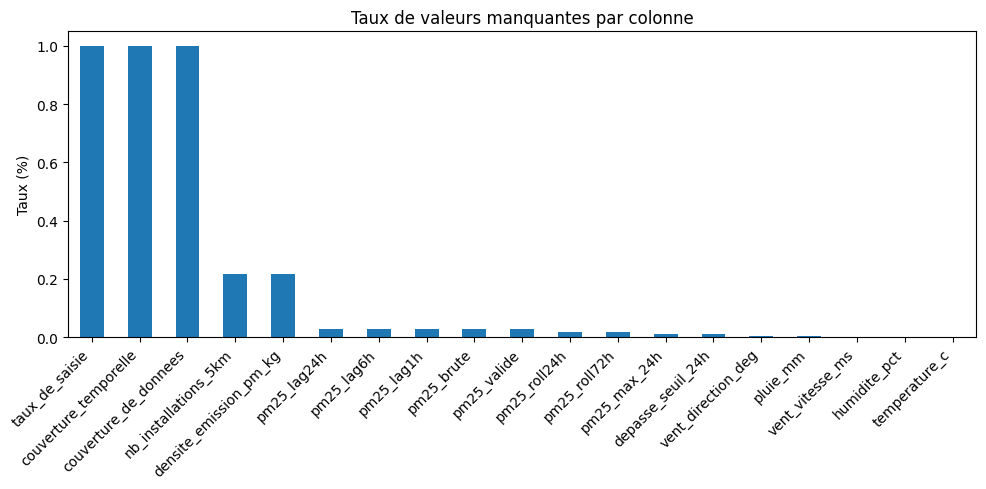

In [10]:
# Taux de valeurs manquantes par colonne
na_pct = df.isna().mean().sort_values(ascending=False)
na_pct = na_pct[na_pct > 0]

print("Colonnes avec valeurs manquantes :")
print((na_pct * 100).round(1).to_string())

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
na_pct.plot(kind="bar", ax=ax)
ax.set_title("Taux de valeurs manquantes par colonne")
ax.set_ylabel("Taux (%)")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 5. Nettoyage

### 5.1 Suppression des colonnes inutiles pour la modélisation

Les colonnes suivantes sont supprimées car elles ne sont pas des features 
pour le modèle — ce sont des métadonnées administratives ou des colonnes 
redondantes.

In [11]:
cols_a_supprimer = [
    "datetime_fin",
    "organisme",
    "code_zas",
    "zas",
    "polluant",
    "type_d_influence",
    "reglementaire",
    "type_d_evaluation",
    "type_de_valeur",
    "unite_de_mesure",
    "taux_de_saisie",           # 100% NaN
    "couverture_temporelle",    # 100% NaN
    "couverture_de_donnees",    # 100% NaN
    "code_qualite",
    "validite",
    "pm25_valide",              # on utilise pm25_brute
    "pm25_max_24h",             # variable intermédiaire
    "code_station_meteo",       # identifiant technique
    "densite_emission_pm_kg",   # émissions non quantifiables
]

cols_presentes = [c for c in cols_a_supprimer if c in df.columns]
df = df.drop(columns=cols_presentes)
print(f"Colonnes supprimées : {len(cols_presentes)}")
print(f"Shape après suppression : {df.shape}")
print(f"\nColonnes restantes :")
print(df.columns.tolist())

Colonnes supprimées : 19
Shape après suppression : (722740, 26)

Colonnes restantes :
['datetime_debut', 'code_station', 'nom_station', 'type_station', 'pm25_brute', 'lat', 'lon', 'distance_km', 'vent_vitesse_ms', 'vent_direction_deg', 'temperature_c', 'humidite_pct', 'pluie_mm', 'annee', 'nb_installations_5km', 'heure', 'jour_semaine', 'mois', 'is_weekend', 'saison', 'pm25_lag1h', 'pm25_lag6h', 'pm25_lag24h', 'pm25_roll24h', 'pm25_roll72h', 'depasse_seuil_24h']


In [12]:
from src.features import imputer_par_fenetre

cols_a_imputer = [
    "pm25_brute",
    "temperature_c",
    "vent_vitesse_ms",
    "vent_direction_deg",
    "humidite_pct",
    "pluie_mm",
    #"nb_installations_5km",
]

df = imputer_par_fenetre(df, cols_a_imputer, fenetre=6)

print("NaN après imputation :")
print((df[cols_a_imputer].isna().mean() * 100).round(1).to_string())

2026-04-21 10:46:28,331 - INFO - Imputation pm25_brute : NaN résiduels = 1.4%
2026-04-21 10:46:28,437 - INFO - Imputation temperature_c : NaN résiduels = 0.1%
2026-04-21 10:46:28,543 - INFO - Imputation vent_vitesse_ms : NaN résiduels = 0.1%
2026-04-21 10:46:28,642 - INFO - Imputation vent_direction_deg : NaN résiduels = 0.3%
2026-04-21 10:46:28,732 - INFO - Imputation humidite_pct : NaN résiduels = 0.1%
2026-04-21 10:46:28,837 - INFO - Imputation pluie_mm : NaN résiduels = 0.3%


NaN après imputation :
pm25_brute            1.4
temperature_c         0.1
vent_vitesse_ms       0.1
vent_direction_deg    0.3
humidite_pct          0.1
pluie_mm              0.3


In [13]:
# Imputation par la médiane par station pour les NaN résiduels
cols_mediane = [
    "pm25_brute",
    "temperature_c", 
    "vent_vitesse_ms",
    "vent_direction_deg",
    "humidite_pct",
    "pluie_mm",
]

for col in cols_mediane:
    df[col] = df.groupby("code_station")[col].transform(
        lambda x: x.fillna(x.median())
    )

print("NaN résiduels après imputation médiane :")
print((df[cols_mediane].isna().mean() * 100).round(1).to_string())

NaN résiduels après imputation médiane :
pm25_brute            0.0
temperature_c         0.0
vent_vitesse_ms       0.0
vent_direction_deg    0.0
humidite_pct          0.0
pluie_mm              0.0


In [14]:
df["nb_installations_5km"] = df["nb_installations_5km"].fillna(0)

In [15]:
# Recalcul des lags après imputation de pm25_brute
df = add_lags(df)

2026-04-21 10:47:16,108 - INFO - Lags PM2.5 ajoutés : lag1h, lag6h, lag24h, roll24h, roll72h
2026-04-21 10:47:16,114 - INFO - Taux de remplissage lags : lag1h=100.0% | lag24h=99.9% | roll24h=100.0%


Colonnes avec valeurs manquantes :
depasse_seuil_24h    1.0
pm25_roll72h         0.1
pm25_lag24h          0.1
pm25_roll24h         0.0
pm25_lag6h           0.0
pm25_lag1h           0.0


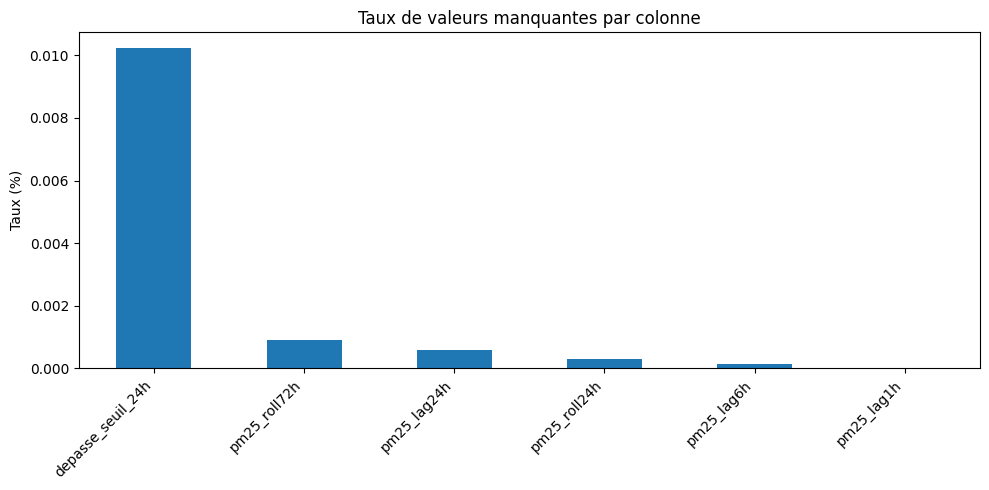

In [16]:
# Taux de valeurs manquantes par colonne
na_pct = df.isna().mean().sort_values(ascending=False)
na_pct = na_pct[na_pct > 0]

print("Colonnes avec valeurs manquantes :")
print((na_pct * 100).round(1).to_string())

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
na_pct.plot(kind="bar", ax=ax)
ax.set_title("Taux de valeurs manquantes par colonne")
ax.set_ylabel("Taux (%)")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 5.2 Suppression des lignes sans variable cible

Les lignes où `depasse_seuil_24h` est NaN correspondent aux dernières heures 
de chaque station (pas assez d'observations futures pour calculer la cible) 
et aux trous dans les séries temporelles. Elles ne peuvent pas être utilisées 
pour l'entraînement du modèle.

In [17]:
n_avant = len(df)
df = df.dropna(subset=["depasse_seuil_24h"])
n_apres = len(df)
print(f"Lignes supprimées (cible NaN) : {n_avant - n_apres:,} ({(n_avant-n_apres)/n_avant:.1%})")
print(f"Shape final : {df.shape}")

Lignes supprimées (cible NaN) : 7,390 (1.0%)
Shape final : (715350, 26)


In [18]:
# Résumé final des NaN
na_final = df.isna().mean()
na_final = na_final[na_final > 0].sort_values(ascending=False)
print("NaN résiduels dans le DataFrame final :")
print((na_final * 100).round(1).to_string())

NaN résiduels dans le DataFrame final :
pm25_roll72h    0.1
pm25_lag24h     0.1
pm25_roll24h    0.0
pm25_lag6h      0.0
pm25_lag1h      0.0


## 6. Sauvegarde sur S3

In [ ]:
import io
import boto3
from dotenv import load_dotenv
load_dotenv()

s3 = boto3.client(
    "s3",
    endpoint_url          = os.getenv("S3_ENDPOINT_URL"),
    aws_access_key_id     = os.getenv("S3_ACCESS_KEY"),
    aws_secret_access_key = os.getenv("S3_SECRET_KEY"),
    aws_session_token     = os.getenv("S3_SESSION_TOKEN"),
)
BUCKET = os.getenv("S3_BUCKET")
KEY    = "projet-qualite-air/processed/dataset_consolide.csv"

# Sauvegarde en mémoire puis upload
buffer = io.StringIO()
df.to_csv(buffer, index=False)
buffer.seek(0)
s3.put_object(Bucket=BUCKET, Key=KEY, Body=buffer.getvalue())

print(f"✓ Dataset sauvegardé : s3://{BUCKET}/{KEY}")
print(f"  Lignes  : {len(df):,}")
print(f"  Colonnes: {len(df.columns)}")
print(f"  Taille  : {len(buffer.getvalue()) / 1e6:.1f} Mo")

✓ Dataset sauvegardé : s3://ganlea/projet-qualite-air/processed/dataset_consolide.csv
  Lignes  : 715,350
  Colonnes: 26
  Taille  : 0.0 Mo
